In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from scipy import integrate

In [2]:
model_variants = ["yolov5nu", "yolov5su", "yolov5mu", "yolov5lu"]
quant_model_variants = ["yolov5nu.quant", "yolov5su.quant", "yolov5mu.quant", "yolov5lu.quant"]
results_dir = Path("../raw_data/onnx_quantize_models_cpu")

In [3]:
def read_model(model_name):
    power_df = pd.read_csv(results_dir / model_name / f"{model_name}_power_log.log", names=["time", "voltage", "current"], parse_dates=[0])
    with open(results_dir / model_name / f"{model_name}_pytorch.json") as f:
        timings = json.load(f)
    with open(results_dir / model_name / "validation_results.json") as f:
        results = json.load(f)
    return power_df, timings, results


In [4]:
idle_power = 3889678.687218899

In [5]:
def calculate_metrics(model_name: str, plot=False):
    """Calculates metrics and returns a dict with all metrics for a given model measurements.

    'Active' part is defined as part of the time series between the first and the last instance 
    of power readings above a certain arbitrary threshold, e.g. 1 W.
    

    Returns: 
        a dict of:
        "mean_active_power": mean power of the 'active' part of the measurements in W
        "max_active_power": max power of the 'active' part of the measurements in W
        "wall_time": time we recorded before and after validation method was called in sec
        "active_time": time taken by the 'active' part of the measurements in sec
        "inference_time": inference time as reported by ultralytics in sec
        "mean_active_energy": energy according to mean power and active time in J
        "max_active_energy": energy according to max power and active time in J
        "mean_inference_energy": energy according to mean power and inference time in J
        "max_inference_energy": energy according to max power and inference time in J
        "integrated_energy": energy by integration (trapezoid method) in J
    """
    power_df, timings, ultralytics_results = read_model(model_name)
    
    start_time = pd.to_datetime(timings["start_time"], unit='s')
    end_time = pd.to_datetime(timings["end_time"], unit='s')
    wall_time = (end_time - start_time).total_seconds()
    inference_time = ultralytics_results["speed"]["inference"]
    power_profile = power_df[(power_df.time >= start_time) & (power_df.time <= end_time)]
    # Get power profile subtracting the idle power
    power_profile.loc[:, ["power"]] = (power_profile.current * power_profile.voltage - idle_power) / 10**6

    # Get framework overhead power (the low parts before and after active part)
    framework_power_overhead = power_profile.power.iloc[:100].mean()
    power_profile.loc[:, "power"] = (power_profile.power - framework_power_overhead)
    filtered_time = power_profile[power_profile.power > 1].time
    active_power_profile = power_profile.loc[(power_df.time >= filtered_time.min()) & (power_df.time <= filtered_time.max())]
    
    if plot:
        sns.lineplot(power_profile, x="time", y="power")
        sns.lineplot(active_power_profile, x="time", y="power")
        plt.show()
    
    mean_active_power = active_power_profile.power.mean()
    max_active_power = active_power_profile.power.max()
    active_time = (active_power_profile.time.iloc[-1] - active_power_profile.time.iloc[0]).total_seconds()
    integrated_energy = integrate.trapezoid(active_power_profile.power, x=active_power_profile.time.apply(lambda x: x.timestamp()))
    result = {
        "mean_active_power": mean_active_power,
        "max_active_power": max_active_power,
        "wall_time": wall_time,
        "active_time": active_time,
        "inference_time": inference_time,
        "mean_active_energy": mean_active_power * active_time,
        "max_active_energy": max_active_power * active_time,
        "mean_inference_energy": mean_active_power * inference_time,
        "max_inference_energy": max_active_power * inference_time,
        "integrated_energy": integrated_energy,
    }
    result.update(ultralytics_results["metrics"])
    return result


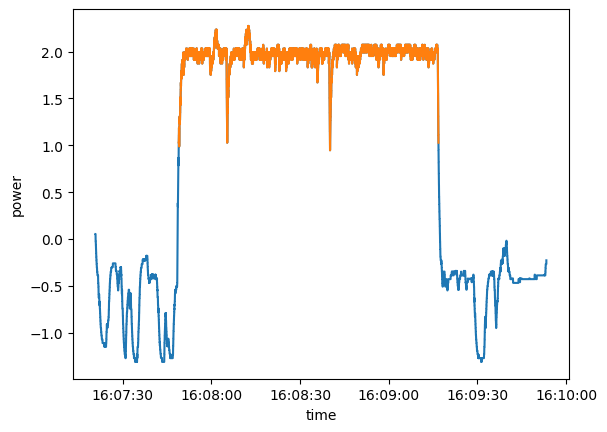

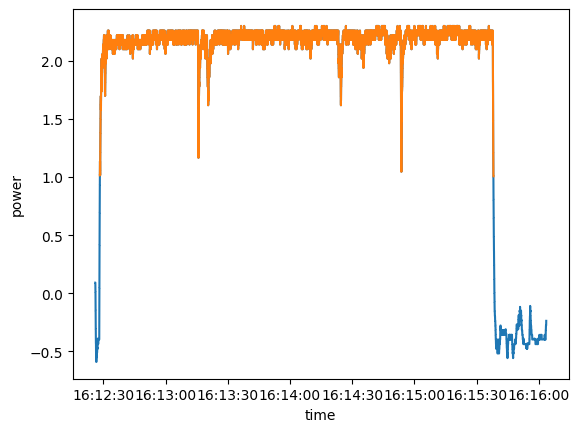

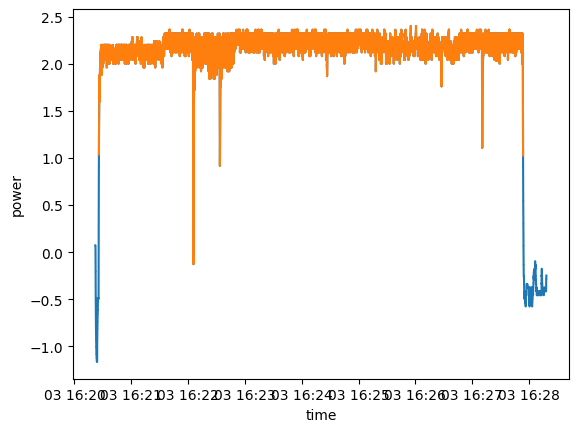

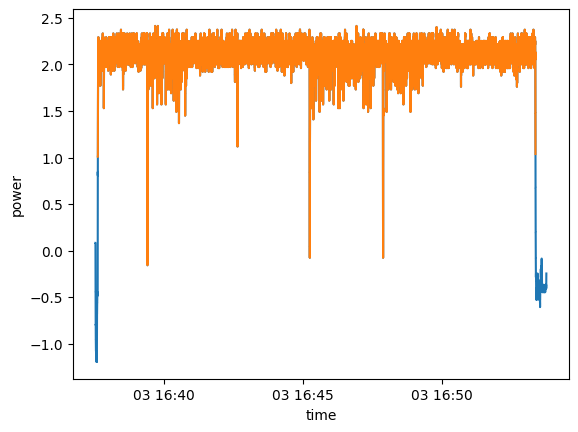

In [6]:
measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, plot=True) for model_name in model_variants}).T

In [7]:
measurements_df

,mean_active_power,max_active_power,wall_time,active_time,inference_time,mean_active_energy,max_active_energy,mean_inference_energy,max_inference_energy,integrated_energy,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
yolov5nu,1.967314,2.273518,152.550379,87.869692,150.576807,172.867305,199.773333,296.231913,342.339094,172.781948,0.598330,0.458862,0.512687,0.363922,0.378798
yolov5su,2.196278,2.301848,217.403242,189.745484,354.376892,416.733907,436.765202,778.310311,815.721627,416.611420,0.725598,0.542873,0.614107,0.458419,0.473987
yolov5mu,2.200700,2.403884,475.997832,447.755334,868.198447,985.375065,1076.351668,1910.644132,2087.047939,985.211866,0.685307,0.623068,0.671167,0.517078,0.532487
yolov5lu,2.140436,2.414333,972.195905,943.540697,1852.045906,2019.588447,2278.021857,3964.185674,4471.456362,2019.010013,0.716409,0.649791,0.706582,0.555251,0.570384


Model Quantization Measurements

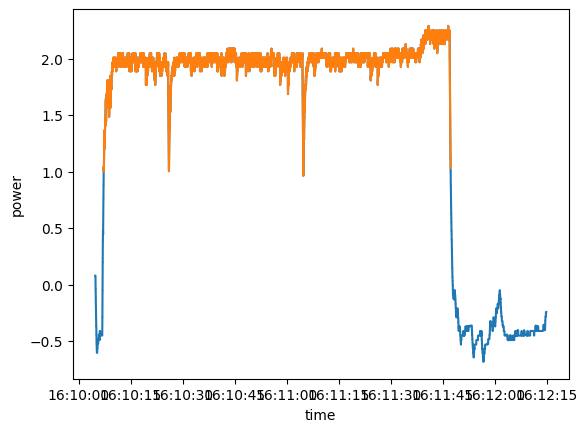

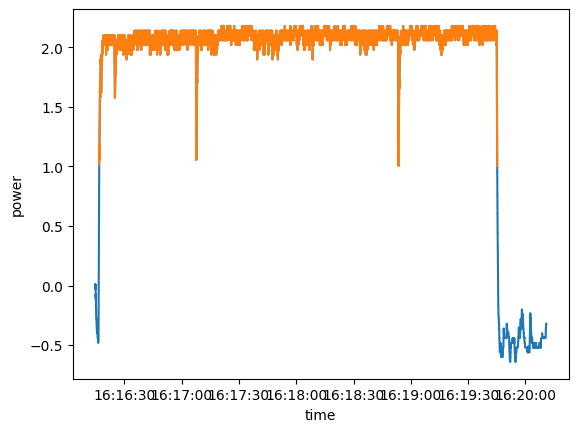

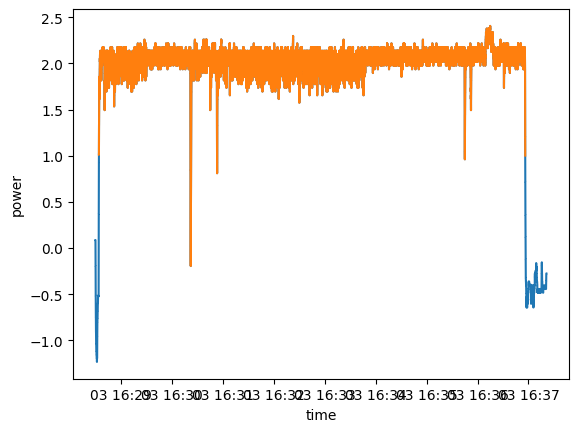

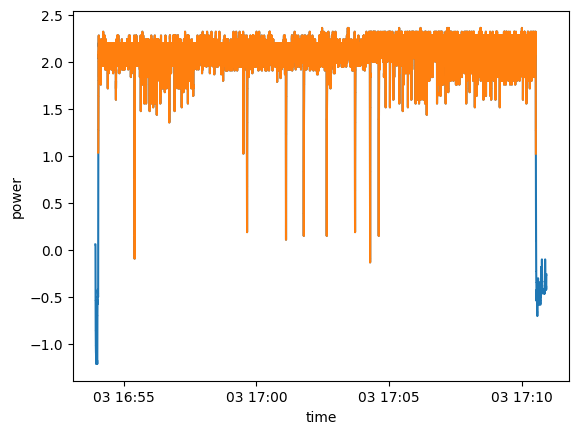

In [8]:
quant_measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, plot=True) for model_name in quant_model_variants}).T

In [9]:
quant_measurements_df

,mean_active_power,max_active_power,wall_time,active_time,inference_time,mean_active_energy,max_active_energy,mean_inference_energy,max_inference_energy,integrated_energy,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
yolov5nu.quant,1.986574,2.289336,130.097333,100.087911,174.576520,198.832073,229.134890,346.809231,399.664368,198.733159,0.584919,0.445373,0.500369,0.348049,0.363281
yolov5su.quant,2.089671,2.179612,236.012376,208.349806,391.566023,435.382600,454.121771,818.244262,853.462065,435.287289,0.686345,0.536246,0.593575,0.435495,0.451303
yolov5mu.quant,2.074024,2.405727,531.618631,502.604778,969.958419,1042.414261,1209.129744,2011.716827,2333.454887,1042.049631,0.696109,0.586812,0.659530,0.502056,0.517803
yolov5lu.quant,2.115392,2.360806,1019.779680,989.617901,1937.758001,2093.430223,2336.296274,4099.118620,4574.671490,2092.872104,0.722061,0.641225,0.694830,0.538118,0.553789


In [10]:
def scatter_text(x, y, text_column, data, title, xlabel, ylabel):
    """Scatter plot with country codes on the x y coordinates
       Based on this answer: https://stackoverflow.com/a/54789170/2641825"""
    # Create the scatter plot
    p1 = sns.scatterplot(x=x, y=y, data=data, size = 8, legend=False)
    # Add text besides each point
    for line in range(0,data.shape[0]):
         p1.text(data[x][line]+0.01, data[y][line], 
                 data[text_column][line], horizontalalignment='left', 
                 size='medium', color='black', weight='semibold')
    # Set title and axis labels
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    return p1

<Axes: title={'center': 'YOLOv5 Baseline'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

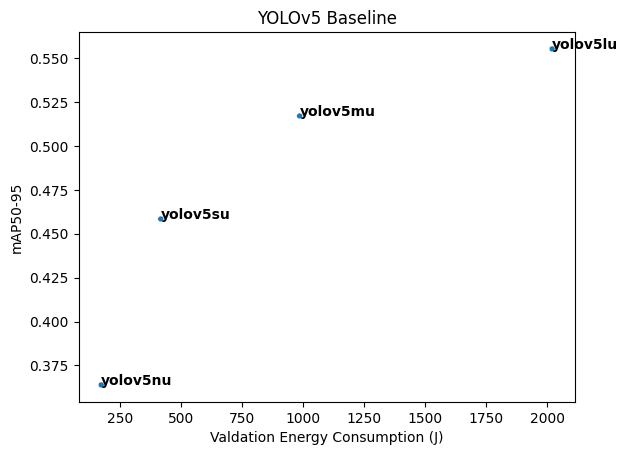

In [11]:
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=measurements_df.reset_index(), title="YOLOv5 Baseline", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

<Axes: title={'center': 'YOLOv5 Model Quantization (INT8 ONNX)'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

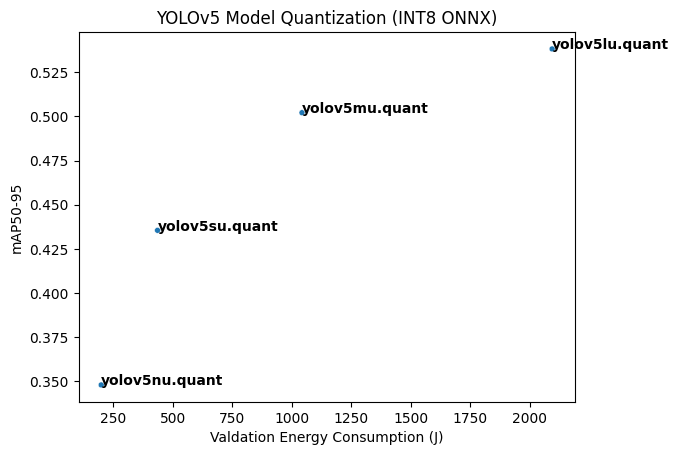

In [12]:
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=quant_measurements_df.reset_index(), title="YOLOv5 Model Quantization (INT8 ONNX)", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

<Axes: title={'center': 'YOLOv5 Baseline and Model Quantization'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

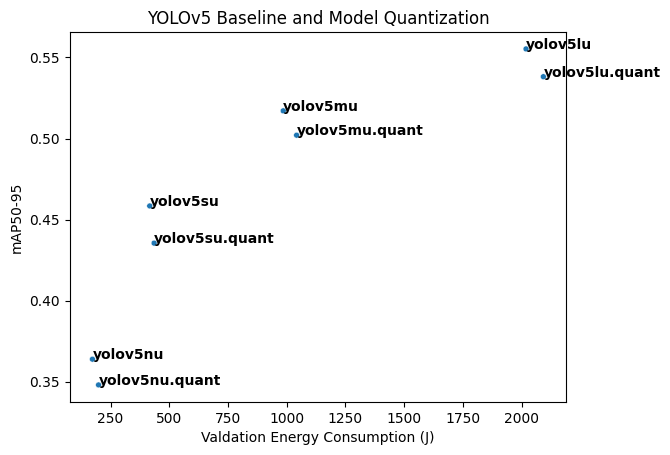

In [13]:
df = pd.concat([measurements_df.reset_index(), quant_measurements_df.reset_index()], ignore_index=True)
scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=df.reset_index(), title="YOLOv5 Baseline and Model Quantization", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")

In [14]:
df.to_csv("../processed_data/model_quantization_measurements.csv")